# MediaPipe Hand Tracking for Robotics
MediaPipe uses a two-stage machine learning pipeline:
1. A **palm detector** that finds the bounding box of a hand.
2. A **hand landmark model** that predicts 21 3D keypoints inside that box.

### **Cell 1: Environment Setup**
Use a Python virtual environment so this notebook's packages stay isolated from the rest of your computer. From a terminal opened in this notebook's directory, run:

**macOS/Linux**
```bash
python3.10 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

**Windows (PowerShell)**
```powershell
py -3.10 -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

In VS Code, click **Select Kernel** in the top-right, choose **Python Environments**, and select the `.venv` you just created. Restart the kernel if prompted, then run the package-install cell below. `%pip` installs into the notebook's currently selected kernel.

> **Already ran the install cell in base Python 3.10?** No big deal: stop here, create/select `.venv` using the steps above, restart the kernel, and run this cell again. The packages installed in the base environment will not interfere with the virtual environment. You usually do not need to uninstall them; doing so could affect another project that uses the base environment.

The next cell installs the current MediaPipe Tasks package and Matplotlib. MediaPipe supplies NumPy and OpenCV as dependencies. After installation or an upgrade, **restart the notebook kernel** before continuing so Python does not keep an older imported package in memory.

In [1]:
import sys
print(f"Installing into: {sys.executable}")
%pip install --upgrade "mediapipe==0.10.21" "matplotlib<4"

Installing into: /usr/local/bin/python3

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### **Cell 2: Imports and Model Initialization**
Download Google's Hand Landmarker model once and initialize the current MediaPipe Tasks API. The model is cached in `~/.cache/mediapipe`, so later runs do not download it again. This notebook uses `IMAGE` mode because it processes one webcam snapshot; a continuous robotics node should use `VIDEO` or `LIVE_STREAM` mode.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/latest/hand_landmarker.task"
)
MODEL_PATH = Path.home() / ".cache" / "mediapipe" / "hand_landmarker.task"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.exists():
    print("Downloading the Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
landmarker = vision.HandLandmarker.create_from_options(options)
print(f"MediaPipe {mp.__version__}; model ready at {MODEL_PATH}")

MediaPipe 0.10.21; model ready at /Users/adrithiyer/.cache/mediapipe/hand_landmarker.task


I0000 00:00:1790034719.337288 7420016 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790034719.344037 7420231 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790034719.350506 7420232 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### **Cell 3: Processing and Visualization**
In a real ROS node, this logic would live inside your `cv_bridge` image callback. Here, we simulate it by capturing a frame from the webcam.

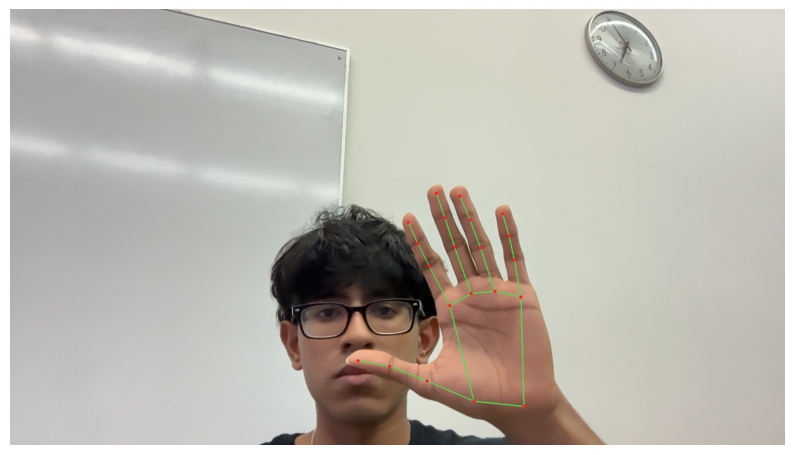

Detected 1 hand(s).


In [4]:
import time

# Open the default webcam using the macOS camera backend.
cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
frame = None

try:
    if not cap.isOpened():
        raise RuntimeError(
            "Could not open the webcam. Check macOS camera permissions "
            "and make sure another app is not using it."
        )

    # Give the camera time to start and let auto-exposure settle.
    time.sleep(1)

    # Discard startup frames, which may be black on macOS.
    for _ in range(30):
        ret, candidate = cap.read()

        if (
            ret
            and candidate is not None
            and candidate.size > 0
            and candidate.max() > 0
        ):
            frame = candidate

        time.sleep(0.03)

    if frame is None:
        raise RuntimeError(
            "The webcam opened but returned only empty or black frames."
        )

    # OpenCV supplies BGR pixels; MediaPipe expects RGB.
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb,
    )

    results = landmarker.detect(mp_image)
    image_bgr = frame.copy()

    # Draw hand landmarks and connections.
    image_height, image_width, _ = image_bgr.shape

    for hand_landmarks in results.hand_landmarks:
        for connection in vision.HandLandmarksConnections.HAND_CONNECTIONS:
            start = hand_landmarks[connection.start]
            end = hand_landmarks[connection.end]

            start_px = (
                int(start.x * image_width),
                int(start.y * image_height),
            )
            end_px = (
                int(end.x * image_width),
                int(end.y * image_height),
            )

            cv2.line(
                image_bgr,
                start_px,
                end_px,
                (80, 220, 80),
                2,
            )

        for landmark in hand_landmarks:
            point = (
                int(landmark.x * image_width),
                int(landmark.y * image_height),
            )

            cv2.circle(
                image_bgr,
                point,
                4,
                (30, 30, 255),
                -1,
            )

    # Display the captured frame in the notebook.
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    if results.hand_landmarks:
        print(f"Detected {len(results.hand_landmarks)} hand(s).")
    else:
        print("Camera frame captured, but no hands were detected.")

finally:
    # Always release the camera, even if detection or plotting fails.
    cap.release()

### **Cell 4: Understanding Depth and Extracting Coordinates**
**Crucial note for robotics:** the Tasks API returns two coordinate sets:
* `results.hand_landmarks` contains normalized image coordinates. `x` and `y` are normalized by image width and height; `z` is relative depth with the wrist near the origin.
* `results.hand_world_landmarks` contains model-estimated 3D coordinates in meters, centered near the hand's geometric center.

World landmarks describe the hand's shape, but they are not automatically coordinates in your robot or camera frame. A ROS application still needs camera calibration and a frame transform; measured depth is preferable when accurate absolute positioning matters.

In [5]:
if 'results' in locals() and results.hand_landmarks:
    # Grab the first detected hand. Landmark 0 is the wrist; 8 is the index tip.
    first_hand = results.hand_landmarks[0]
    first_world_hand = results.hand_world_landmarks[0]
    
    print("--- RAW MEDIAPIPE COORDINATES ---")
    # Landmark 8 is the Index Finger Tip
    index_tip = first_hand[8]
    wrist = first_hand[0]
    
    print(f"Index Tip -> X: {index_tip.x:.4f}, Y: {index_tip.y:.4f}, Z: {index_tip.z:.4f}")
    print(f"Wrist     -> X: {wrist.x:.4f}, Y: {wrist.y:.4f}, Z: {wrist.z:.4f}\n")

    world_index_tip = first_world_hand[8]
    print("--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---")
    print(
        f"Index Tip -> X: {world_index_tip.x:.4f}, "
        f"Y: {world_index_tip.y:.4f}, Z: {world_index_tip.z:.4f}\n"
    )
    
    print("--- CONVERTING TO PIXEL COORDINATES ---")
    if 'frame' in locals():
        image_height, image_width, _ = frame.shape
        
        # De-normalize X and Y to get pixel coordinates
        pixel_x = int(index_tip.x * image_width)
        pixel_y = int(index_tip.y * image_height)
        print(f"Index Tip is at pixel: ({pixel_x}, {pixel_y})")
else:
    print("No hands detected in the frame. Run Cell 3 again to capture a frame.")

--- RAW MEDIAPIPE COORDINATES ---
Index Tip -> X: 0.5139, Y: 0.4892, Z: -0.0489
Wrist     -> X: 0.6634, Y: 0.9114, Z: 0.0000

--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---
Index Tip -> X: -0.0546, Y: -0.0530, Z: -0.0336

--- CONVERTING TO PIXEL COORDINATES ---
Index Tip is at pixel: (986, 528)


### **Next Steps (the part where YOU guys do stuff!!)**
First, if Ethan does not go over handtracking demo with you, take a shot at 
running it with your webcam! See what it looks like to run it live in a video 
and observe how it collects data.

Now, the fun part! There are a LOT of questions that need to be arbitrated 
on the software side. These include, as examples:
- How does one reduce jitter? The positions are predictions made by the model 
at a given point in time on a given frame and are thus not inherently smoothed 
between frames; this is BAD if we are moving an end effector of an arm
based on this data.
- How does one turn 21 landmarks into a single point that the end effector will
moved bassed on? Different hand positions might lend to different answers if we 
do not well-define an approach.
- How to depth estimate? We do NOT own an RGB-D camera (one with fancy depth 
software). What challenges may this bring and how may we overcome them?
- We take this data; how does one interface it with the rest of the ROS 
ecosystem? How does one write the tf2 that will transmit this point data effectively?
- Doing ALL of this; how can we minimize latency in this system? Note right now
we are calling an API...

This list is not necessarily exhaustive; it's up to y'all to think like 
software designers and come up with these questions pre-emptively!

Your task is to take an open design question and explore it; find different 
approaches to how to tackle the design question and provide Ethan both a short 
documented explanation of this question and an attempt at implementing a 
contained approach (whether it be in a copy of this notebook, in the `hand_tracking_demo.py` 
file, or in an entirely separate file). Feel free to work in pairs or small groups!

Put all of this stuff into a directory titled with your first initial and last name (e.g. `egopez` for me!) in a git branch
titled `vha_onboarding_<FIRST_INITIAL><LASTNAME>` (e.g. `vha_onboarding_egopez`).
If multiple people in a group, append the names.